<a href="https://colab.research.google.com/github/Kabaaaan/Simulation_modeling/blob/main/IM_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Задание 1.1. Метод контрольных случайных величин

In [ ]:
# @title 1 задание

# Некоторая система состоит из 𝑛 независимых элементов, которые могут оказаться в нерабочем состоянии с известными вероятностями 𝑝𝑖, 𝑖 = 1, ..., 𝑛.
# Пусть 𝑁 – число неисправных элементов. Требуется найти оценку веротности P(𝑁 ≤ 𝑘),
# (в качестве контрольной случайной величины взять 𝑁).

import numpy as np

n = 50
k = 3
m = 10000

p = np.random.uniform(0.01, 0.1, size=n)
E_Y = np.sum(p)  # мат ожидание числа отказов

# Генерация состояний системы
u = np.random.rand(m, n)
failures = (u < p)
N = failures.sum(axis=1) # количество неисправных

X = (N <= k).astype(float)  # Целевая С.В.
Y = N                       # Контрольная С.В.

theta_mc = X.mean()
var_mc = X.var(ddof=1) / m


# Метод контрольных С.В.

X_mean = X.mean()
Y_mean = Y.mean()

cov_XY = np.cov(X, Y, ddof=1)[0, 1]  # оценка ковариации
var_Y = np.var(Y, ddof=1)            # дисперсия контрольной величины

c = - cov_XY / var_Y

theta_cv = X_mean + c * (E_Y - Y_mean)

Z = X + c * (Y - E_Y)
var_cv = np.var(Z, ddof=1) / m

print("Метод Монте-Карло:")
print("Оценка =", theta_mc)
print("Дисперсия оценки =", var_mc)

print("\nМетод контрольных случайных величин:")
print("Оценка =", theta_cv)
print("Дисперсия оценки =", var_cv)

print("\nВо сколько раз уменьшилась дисперсия:")
print(var_mc / var_cv)

Задание 1.2. Метод существенной выборки

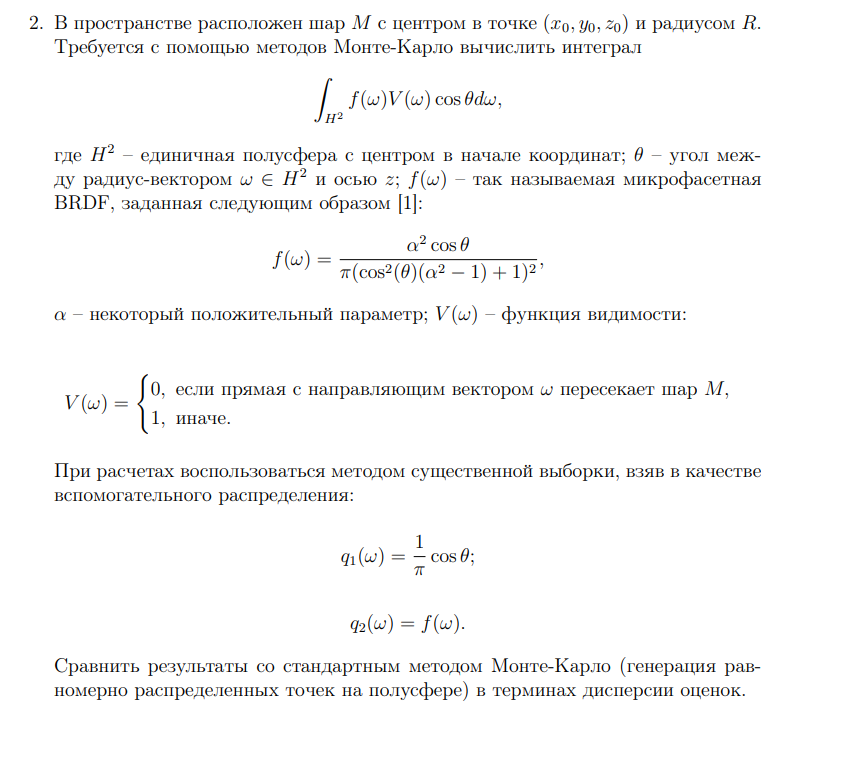

In [ ]:
# @title 2 задание

# https://libeldoc.bsuir.by/bitstream/123456789/60437/1/Sakun_Metody.pdf

import numpy as np


ALPHA = 0.5
CENTER = np.array([0.4, 0.8, 0.8])
RADIUS = 0.3
N_SAMPLES = 100_000


def sample_uniform_hemisphere(n_samples: int):
    phi = 2 * np.pi *  np.random.rand(n_samples)
    cos_theta =  np.random.rand(n_samples)   # cosθ от 0 до 1 - полусфера
    sin_theta = np.sqrt(1 - cos_theta**2)

    omega_x = sin_theta * np.cos(phi)
    omega_y = sin_theta * np.sin(phi)
    omega_z = cos_theta

    omega = np.column_stack((omega_x, omega_y, omega_z))
    return omega, cos_theta

def sample_cosine_weighted_hemisphere(n_samples: int):
    phi = 2 * np.pi * np.random.rand(n_samples)
    cos_theta = np.sqrt(1 - np.random.rand(n_samples))           # √(1-u) → cosθ
    sin_theta = np.sqrt(1 - cos_theta**2)

    omega_x = sin_theta * np.cos(phi)
    omega_y = sin_theta * np.sin(phi)
    omega_z = cos_theta

    omega = np.column_stack((omega_x, omega_y, omega_z))
    return omega, cos_theta


def sample_brdf_weighted(n_samples: int, alpha: float):
    xi = np.random.rand(n_samples)
    phi = 2 * np.pi * np.random.rand(n_samples)

    alpha_sq = alpha**2
    beta = alpha_sq - 1.0

    # Обратная функция распределения для cos²θ
    cos2_theta = xi / (alpha_sq - xi * beta)
    cos_theta = np.sqrt(np.clip(cos2_theta, 0, 1))
    sin_theta = np.sqrt(np.maximum(1 - cos2_theta, 0))

    omega_x = sin_theta * np.cos(phi)
    omega_y = sin_theta * np.sin(phi)
    omega_z = cos_theta

    omega = np.column_stack((omega_x, omega_y, omega_z))
    return omega, cos_theta


def compute_visibility(omega: np.ndarray, center: np.ndarray, radius: float) -> np.ndarray:
    dot = np.dot(omega, center)  # dot = ω · C
    discriminant = dot**2 - (np.dot(center, center) - radius**2) # discriminant = dot² - (|C|² - R²)
    return np.where(discriminant < 0, 1.0, 0.0) # Если дискриминант < 0 → нет пересечения → видим


def ggx_brdf(cos_theta: np.ndarray, alpha: float) -> np.ndarray:
    """Микрофасетная BRDF"""
    alpha_sq = alpha**2 * cos_theta
    denom = np.pi * (cos_theta**2 * (alpha_sq - 1) + 1)**2
    return alpha_sq * cos_theta / denom


# равномерная выборка
omega_u, cos_theta_u = sample_uniform_hemisphere(N_SAMPLES)
V_u = compute_visibility(omega_u, CENTER, RADIUS)
f_u = ggx_brdf(cos_theta_u, ALPHA)
integrand_u = f_u * V_u * cos_theta_u
pdf_u = 1.0 / (2 * np.pi)
estimator_u = integrand_u / pdf_u

est_uniform = np.mean(estimator_u)
var_uniform = np.var(estimator_u, ddof=1) / N_SAMPLES

# существенная выборка q₁ = cosθ / π
omega_c, cos_theta_c = sample_cosine_weighted_hemisphere(N_SAMPLES)
V_c = compute_visibility(omega_c, CENTER, RADIUS)
f_c = ggx_brdf(cos_theta_c, ALPHA)
integrand_c = f_c * V_c * cos_theta_c
pdf_c = cos_theta_c / np.pi
estimator_c = integrand_c / pdf_c

est_q1 = np.mean(estimator_c)
var_q1 = np.var(estimator_c, ddof=1) / N_SAMPLES

# существенная выборка q₂ = f(ω)
omega_f, cos_theta_f = sample_brdf_weighted(N_SAMPLES, ALPHA)
V_f = compute_visibility(omega_f, CENTER, RADIUS)
f_f = ggx_brdf(cos_theta_f, ALPHA)          # ≈ pdf (но без 1/π в азимуте)
integrand_f = f_f * V_f * cos_theta_f
pdf_f = f_f                                 # здесь pdf = f(ω)
estimator_f = integrand_f / pdf_f           # → просто V * cosθ

est_q2 = np.mean(estimator_f)
var_q2 = np.var(estimator_f, ddof=1) / N_SAMPLES



print(f"MC: {est_uniform:12.6f} ± {np.sqrt(var_uniform):.2e}")
print(f"q1: {est_q1:12.6f} ± {np.sqrt(var_q1):.2e}")
print(f"q2: {est_q2:12.6f} ± {np.sqrt(var_q2):.2e}")
print()
print(f"Дисперсия оценок :")
print(f"MC: {var_uniform:.2e}")
print(f"q1: {var_q1:.2e}")
print(f"q2: {var_q2:.2e}")



Задание №3 - Моделирование распространения излучения в многослойных средах

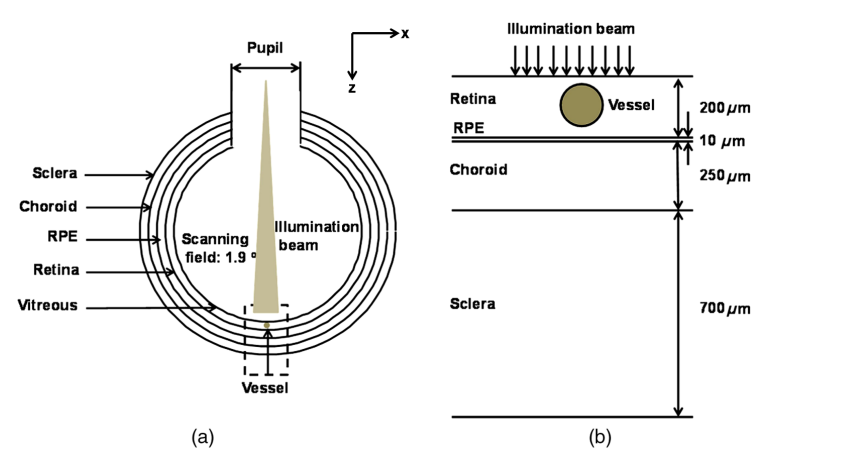

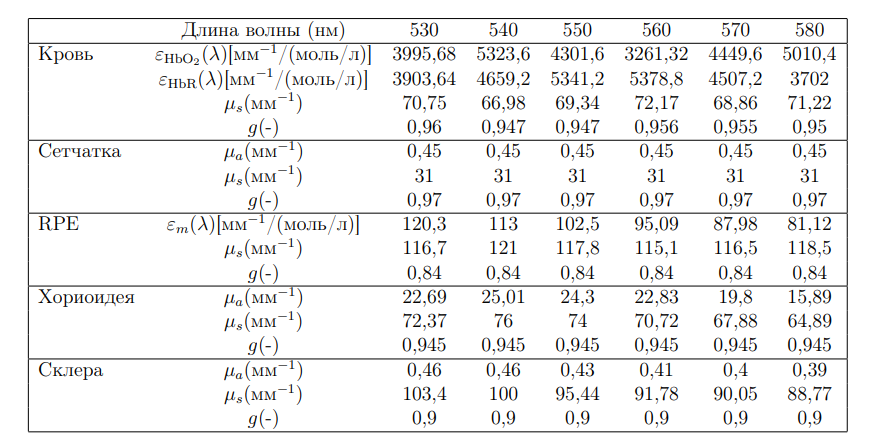

In [ ]:
# @title Задание №3

import numpy as np
import matplotlib.pyplot as plt

C_m = 4.0                    # Молекулярная концентрация меланина в RPE (моль/л) 4–8 моль/л
sO2 = 0.7                    # Уровень насыщения кислородом (sO2 = 70%)
Hb_tot = 150.0               # Парциальная плотность гемоглобина (г/л)
D_mm = 0.1                   # Диаметр кровеносного сосуда (мм) Может варьироваться 40–160 мкм
z_vessel_top = 0.01          # Глубина верхней стенки сосуда под ретиной (мм) - 10 мкм ниже уровня сетчатки
rv = D_mm / 2                # Радиус сосуда (мм)
z_c = z_vessel_top + rv      # Координата центра цилиндра сосуда по z
pupil_r = 3.5                # Радиус зрачка (мм) — диаметр 7 мм
theta_max_deg = 1.9          # Максимальный угол сканирования (градусы)
W_th = 1e-4                  # Пороговое значение статистического веса для поглощения
m = 10
max_z = 1.16
N_photons = 100000

# 0.00 – 0.20 : Сетчатка
# 0.20 – 0.21 : РПЕ
# 0.21 – 0.46 : Хороид
# 0.46 – 1.16 : Склера
layer_bounds = np.array([0.0, 0.2, 0.21, 0.46, 1.16])

# Оптические параметры λ=550 нм
eps_HbO2 = 4301.6
eps_HbR = 5341.2
mu_s_blood = 69.34
g_blood = 0.947

mu_a_retina = 0.45
mu_s_retina = 31.0
g_retina = 0.97

eps_m_RPE = 102.5
mu_s_RPE = 117.8
g_RPE = 0.84

mu_a_choroid = 24.3
mu_s_choroid = 74.0
g_choroid = 0.945

mu_a_sclera = 0.43
mu_s_sclera = 95.44
g_sclera = 0.9

ln10 = np.log(10)
mu_a_blood = ln10 * Hb_tot * (eps_HbO2 * sO2 + eps_HbR * (1 - sO2)) / 64500
mu_a_RPE = ln10 * C_m * eps_m_RPE
# print(f"μ_a_blood = {mu_a_blood:.2f}, μ_a_RPE = {mu_a_RPE:.0f} мм⁻¹")

def get_props(x, y, z):
    layer_idx = np.searchsorted(layer_bounds, z, side='right') - 1
    if layer_idx < 0 or layer_idx >= 4:
        return 0.0, 0.0, 0.0
    dist_to_axis = np.sqrt(x**2 + (z - z_c)**2)
    in_vessel = (dist_to_axis <= rv) and (layer_idx == 0)
    if in_vessel:
        return mu_a_blood, mu_s_blood, g_blood
    elif layer_idx == 0:
        return mu_a_retina, mu_s_retina, g_retina
    elif layer_idx == 1:
        return mu_a_RPE, mu_s_RPE, g_RPE
    elif layer_idx == 2:
        return mu_a_choroid, mu_s_choroid, g_choroid
    else:
        return mu_a_sclera, mu_s_sclera, g_sclera

# расстояние до кровеносного сосуда
def dist_to_cylinder(x0, y0, z0, sx, sy, sz):
    a = sx**2 + sz**2
    b = 2*(x0*sx + (z0 - z_c)*sz)
    c = x0**2 + (z0 - z_c)**2 - rv**2
    disc = b*b - 4*a*c
    if disc < 0 or a < 1e-12: return np.inf
    t1 = (-b - np.sqrt(disc))/(2*a)
    t2 = (-b + np.sqrt(disc))/(2*a)
    ts = [t for t in (t1,t2) if t > 1e-8]
    return min(ts) if ts else np.inf

# через какое расстояние фотон достигнет границы текущего слоя ткани
def dist_to_layer(z0, sz, layer_idx):
    if abs(sz) < 1e-12: return np.inf
    z_next = layer_bounds[layer_idx + 1] if sz > 0 else layer_bounds[layer_idx]
    t = (z_next - z0) / sz
    return t if t > 1e-8 else np.inf

def hg_sample(g):
    xi = np.random.rand()
    if abs(g) < 1e-6: return 2*xi - 1
    temp = (1 - g*g) / (1 + g - 2*g*xi)
    return (1 + g*g - temp*temp) / (2*g)

def rotate_direction(sx, sy, sz, cos_th, phi):
    sin_th = np.sqrt(1 - cos_th*cos_th)
    if abs(sz) > 0.999999:
        sxn = sin_th * np.cos(phi)
        syn = sin_th * np.sin(phi)
        szn = cos_th * np.sign(sz)
    else:
        denom = np.sqrt(1 - sz*sz)
        sxn = sin_th*(sx*sz*np.cos(phi) - sy*np.sin(phi))/denom + sx*cos_th
        syn = sin_th*(sy*sz*np.cos(phi) + sx*np.sin(phi))/denom + sy*cos_th
        szn = sz*cos_th - sin_th*np.cos(phi)*np.sqrt(1 - sz*sz)
    n = np.sqrt(sxn**2 + syn**2 + szn**2)
    return sxn/n, syn/n, szn/n



r_max_abs = 0.3
nxz = 120; nr_abs = 60; nz = 140

abs_xz = np.zeros((nxz, nz))
abs_cyl = np.zeros((nr_abs, nz))

# Для R(r, α)
R_r = []
R_alpha = []
total_reflected = 0.0

dx = 2 * r_max_abs / nxz
dz = max_z / nz
dr_abs = r_max_abs / nr_abs


for _ in range(N_photons):
    theta = np.random.rand() * np.deg2rad(theta_max_deg)
    phi = 2*np.pi*np.random.rand()
    sx = np.sin(theta)*np.cos(phi)
    sy = np.sin(theta)*np.sin(phi)
    sz = np.cos(theta)
    x = y = z = 0.0
    W = 1.0

    while W > 0 and z < max_z:
        mua, mus, g = get_props(x, y, z)
        mut = mua + mus
        if mut < 1e-9: break

        layer_idx = np.searchsorted(layer_bounds, z, side='right') - 1
        d_layer = dist_to_layer(z, sz, layer_idx)
        d_cyl = dist_to_cylinder(x, y, z, sx, sy, sz) if layer_idx == 0 else np.inf
        d_inter = -np.log(np.random.rand()) / mut if mut > 0 else np.inf

        d_move = min([d for d in (d_layer, d_cyl, d_inter) if d < np.inf])
        if d_move == np.inf or d_move < 1e-8: break

        x += d_move * sx
        y += d_move * sy
        z += d_move * sz
        # x = x * np.cos(theta) + (np.sin(theta) / np.sqrt(1 - z**2)) * (x*z*np.cos(phi) - y*np.sin(phi))
        # y = y * np.cos(theta) + (np.sin(theta) / np.sqrt(1 - z**2)) * (y*z*np.cos(phi) - x*np.sin(phi))
        # z = z * np.cos(theta) - np.sin(theta)*np.cos(phi)*np.sqrt(1-z**2)

        # Выход через зрачок
        if z <= 1e-6 and sz < -1e-9:
            r_exit = np.sqrt(x*x + y*y)
            if r_exit <= pupil_r:
                alpha = np.arccos(-sz)
                R_r.append(r_exit)
                R_alpha.append(np.rad2deg(alpha))   # в градусах
                total_reflected += W
            break

        # Поглощение
        deltaW = W * mua / mut
        ix = int((x + r_max_abs) / dx)
        iz = int(z / dz)
        if 0 <= ix < nxz and 0 <= iz < nz:
            abs_xz[ix, iz] += deltaW
        r = np.sqrt(x*x + y*y)
        ir = int(r / dr_abs)
        if 0 <= ir < nr_abs and 0 <= iz < nz:
            abs_cyl[ir, iz] += deltaW

        W -= deltaW
        if W < W_th:
            if np.random.rand() < 1.0/m:
                W *= m
            else:
                W = 0.0
        if W > 0 and abs(d_move - d_inter) < 1e-8:
            cos_th = hg_sample(g)
            phi_sc = 2*np.pi*np.random.rand()
            sx, sy, sz = rotate_direction(sx, sy, sz, cos_th, phi_sc)


# print(f"Суммарный вес отраженных фотонов (доля): {total_reflected / N_photons:.5f}")

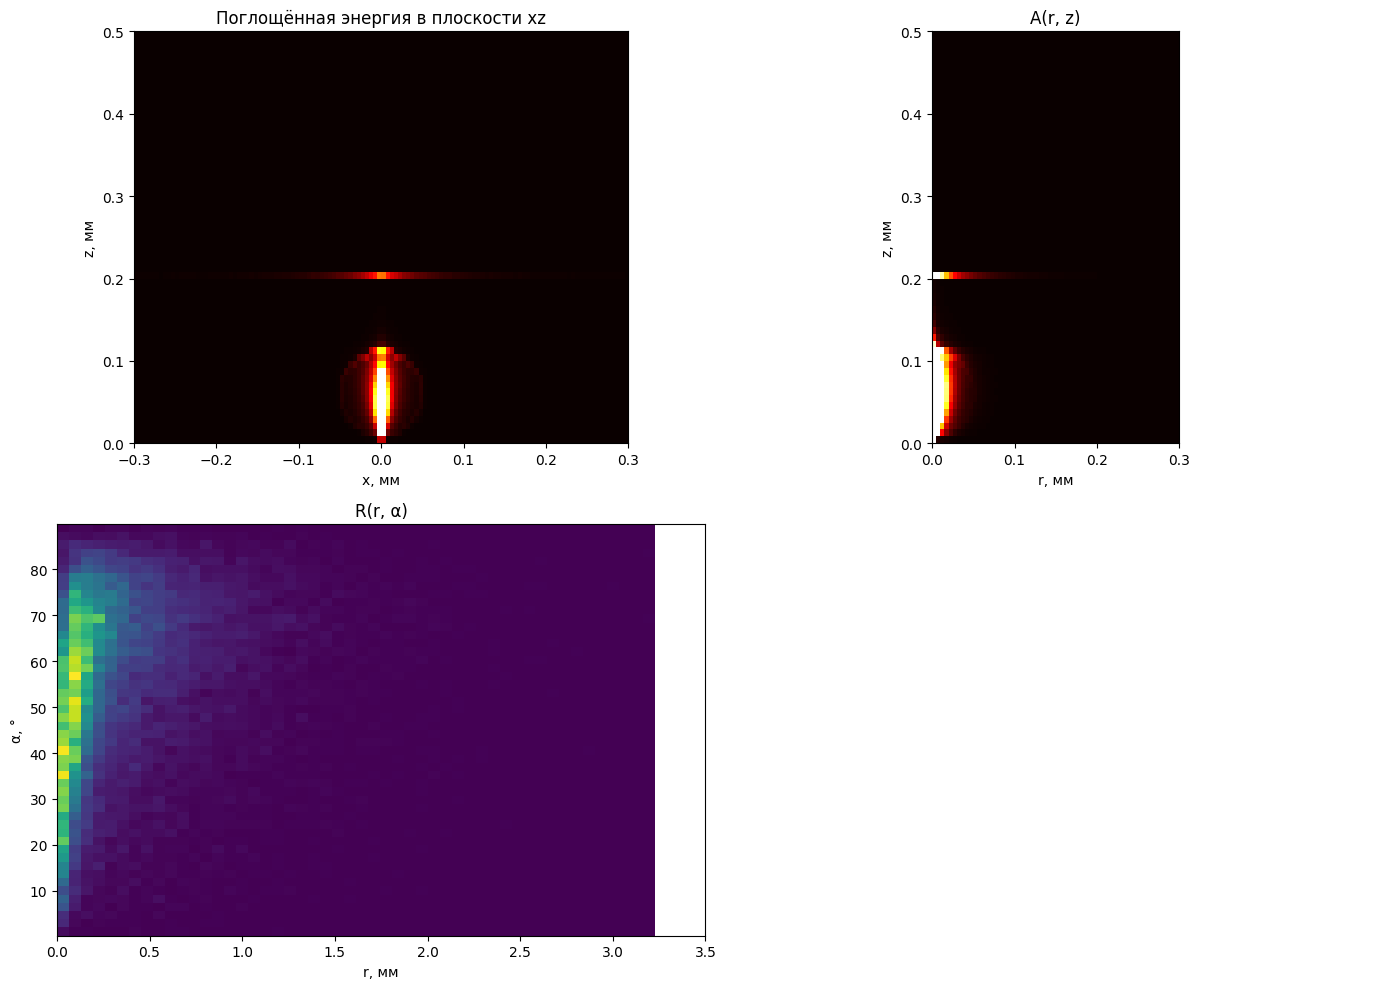

In [ ]:
abs_cyl_display = abs_cyl.copy() / N_photons
r_centers = np.linspace(dr_abs/2, r_max_abs-dr_abs/2, nr_abs)
# делим на объем кольцевой ячейки
volumes = (2 * np.pi * r_centers[:, None] * dr_abs * dz)
abs_cyl_display /= (volumes + 1e-18)

# Определение порога яркости (vmax)
# Чтобы увидеть "тусклое пятно" на 0.2, нам нужно отсечь пик поглощения в самом сосуде
# Возьмем, например, 5-10% от максимума или фиксированное значение
vmax_value = np.max(abs_xz) * 0.1

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Первый график (XZ)
im0 = axs[0,0].imshow(abs_xz.T, origin='lower',
                      extent=[-r_max_abs, r_max_abs, 0, max_z],
                      cmap='hot', vmin=0, vmax=vmax_value)
axs[0,0].set_title('Поглощённая энергия в плоскости xz')
axs[0,0].set_xlabel('x, мм'); axs[0,0].set_ylabel('z, мм')
axs[0,0].set_ylim(0, 0.5) # фокус на верхних слоях

# Второй график (RZ) - теперь с тем же vmax
im1 = axs[0,1].imshow(abs_cyl_display.T, origin='lower',
                      extent=[0, r_max_abs, 0, max_z],
                      cmap='hot', vmin=0, vmax=vmax_value)
axs[0,1].set_title('A(r, z)')
axs[0,1].set_xlabel('r, мм'); axs[0,1].set_ylabel('z, мм')
axs[0,1].set_ylim(0, 0.5)

# Третий график (R(r, alpha))
axs[1,0].hist2d(R_r, R_alpha, bins=50, cmap='viridis')
axs[1,0].set_title('R(r, α)')
axs[1,0].set_xlabel('r, мм')
axs[1,0].set_ylabel('α, °')
axs[1,0].set_xlim(0, 3.5)

axs[1,1].axis('off')
plt.tight_layout()
plt.show()